![image](https://github.com/eWaterCycle/ewatercycle/raw/main/docs/examples/logo.png)

# Generate forcing in eWaterCycle with ESMValTool

This notebooks shows how to generate forcing data for PCR-GLOBWB model using ERA5 data and [ESMValTool hydrological recipes](https://docs.esmvaltool.org/en/latest/recipes/recipe_hydrology.html#pcr-globwb). More information about data, configuration and installation instructions can be found in the [System setup](https://ewatercycle.readthedocs.io/en/latest/system_setup.html) in the eWaterCycle documentation.

In [25]:
import logging
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

In [ ]:
import xarray as xr
#from rich import print
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature
import shutil


import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage



In [27]:
project_root = Path.cwd()

Python: /home/avandervee3/MSc_AralSea/venv/bin/python
Package: /home/avandervee3/ewatercycle-pcrglobwb/src/ewatercycle_pcrglobwb/__init__.py


Forcing for PCRGlobWB is created using the ESMValTool recipe. It produces one file per each variable: temperature, and precipitation. You can set the start and end date, and the region. See [eWaterCycle documentation](https://ewatercycle.readthedocs.io/en/latest/apidocs/ewatercycle.forcing.html#submodules) for more information. 

PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin')

### Plot forcing

In [31]:


# Catchment bounding boxes
clonemap_extents = {
    "kemijoki" : {"latitude" : (64,70), "longitude" : (20,32)},
}

# Set the extent of the forcing data sufficiently larger than the clonemap.
esmvaltool_padding = 0  # degrees lat/lon



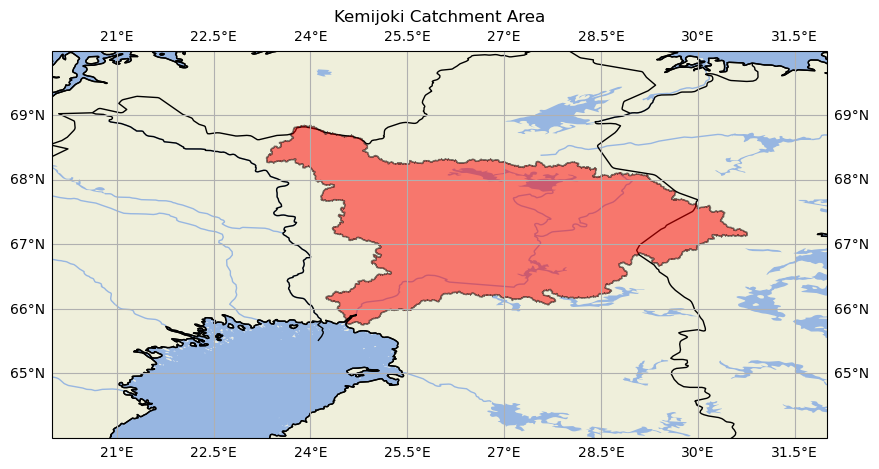

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

clonemap_extents = {
    "kemijoki": {
        "latitude": (64, 70),
        "longitude": (20, 32)
    },
}

shp = shpreader.Reader("./data_example/kemijoki/shapefiles/kemijoki.shp")

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)


ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)

ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

ax.add_geometries(
    shp.geometries(),
    crs=ccrs.PlateCarree(),
    facecolor="red",
    edgecolor="black",
    alpha=0.5
)

extent = clonemap_extents["kemijoki"]

ax.set_extent(
    [
        *extent["longitude"],
        *extent["latitude"],
    ],
    crs=ccrs.PlateCarree()
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title("Kemijoki Catchment Area")
plt.show()

In [33]:
import subprocess
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution."""
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        "an integer number of grid cells."
    )
    assert dlon % forcing_resolution == 0, f"Longitudes not compatible. {msg}"
    assert dlat % forcing_resolution == 0, f"Latitudes not compatible. {msg}"

    clonemap_dir = (
        "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"
    )
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    outputclonemap = f"./data_example/{catchment.lower()}_05min.map"  # copy to clonemap dir after ensuring it is correct

    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap



In [34]:


forcing_resolution = 0.75  # this has to be 0.75
for (catchment, extents) in clonemap_extents.items():
    latmin, latmax = extents["latitude"]
    lonmin, lonmax = extents["longitude"]
    print(
        create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment)
    )



Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.
./data_example/kemijoki_05min.map


In [ ]:

catchment, extents = next(iter(clonemap_extents.items()))

lon_min_f, lon_max_f = extents["longitude"]
lat_min_f, lat_max_f = extents["latitude"]

start_time_ERA5="1995-01-01T00:00:00Z"
end_time_ERA5="2000-12-31T00:00:00Z"

# Forcing data will be stored here
forcing_root =  project_root/f"data_example/{catchment}/forcing"
yaml_files = list(forcing_root.rglob("ewatercycle_forcing.yaml"))

if not yaml_files:
    print("Forcing not found — generating.")
    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
        dataset="ERA5",
        start_time=start_time_ERA5,
        end_time=end_time_ERA5,
        shape=f"./data_example/kemijoki/shapefiles/kemijoki.shp",
        extract_region={
            "start_longitude": lon_min_f - esmvaltool_padding,
            "end_longitude": lon_max_f + esmvaltool_padding,
            "start_latitude": lat_min_f - esmvaltool_padding,
            "end_latitude": lat_max_f + esmvaltool_padding,
        },
        start_time_climatology=start_time_ERA5,
        end_time_climatology=end_time_ERA5,
        directory=forcing_root,
    )

else:
    forcing_yaml = yaml_files[0]
    print(f"Forcing already exists — loading from {forcing_yaml.parent}")

    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
        directory=forcing_yaml.parent,
    )



Forcing already exists — loading from /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/data_example/kemijoki/forcing/work/diagnostic/script


PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/data_example/kemijoki/forcing')

forcing.directory = /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/data_example/kemijoki/forcing/work/diagnostic/script
forcing.temperatureNC = pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1995-2000_kemijoki.nc
forcing.precipitationNC = pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1995-2000_kemijoki.nc


<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 25, lon: 49, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1994-01-01 1994-01-02 ... 2000-12-31
  * lat        (lat) float32 100B 70.0 69.75 69.5 69.25 ... 64.5 64.25 64.0
  * lon        (lon) float32 196B 20.0 20.25 20.5 20.75 ... 31.5 31.75 32.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 13MB 269.8 270.2 270.3 ... 269.9 270.0
    time_bnds  (time, bnds) datetime64[ns] 41kB 1993-12-31T12:00:00 ... 2000-...
    lat_bnds   (lat, bnds) float32 200B 70.12 69.88 69.88 ... 64.12 64.12 63.88
    lon_bnds   (lon, bnds) float32 392B 19.88 20.12 20.12 ... 31.88 31.88 32.12
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.
------------------------
<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 25, lon: 49, bnds: 2)
Coordinat

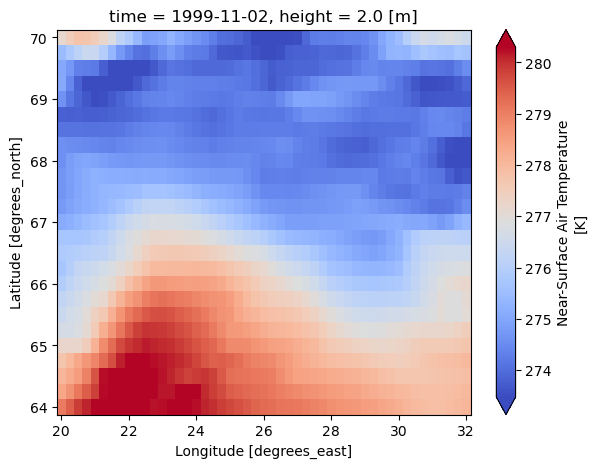

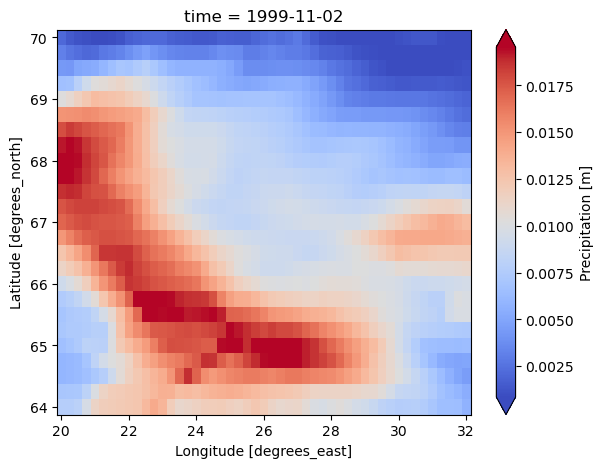

In [38]:
for file_name in [example_forcing.temperatureNC, example_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{example_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-426).plot(cmap="coolwarm", robust=True, size=5)

In [ ]:

pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")
INI_FILES = Path("./data_example")
#INI_FILES = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files")
parameter_set_example = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "uncalibrated.ini",
    target_model="pcrglobwb",
    supported_model_versions={"aralxy5"},
)







my_image = ContainerImage("/home/avandervee3/pcrglob_aralxy5.sif")

cloneMap_path = Path.cwd() /"data_example"/ f"{catchment.lower()}_05min.map"




In [43]:
pcrglob_example = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_example,
    forcing=example_forcing,
    cloneMap=cloneMap_path,
    landmask=cloneMap_path,
    bmi_image = my_image
)

print(pcrglob_example)

parameter_set=ParameterSet(name='custom_parameter_set', directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'), config=PosixPath('data_example/uncalibrated.ini'), doi='N/A', target_model='pcrglobwb', supported_model_versions={'aralxy5'}, downloader=None) forcing=PCRGlobWBForcing(start_time='1995-01-01T00:00:00Z', end_time='2000-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/data_example/kemijoki/forcing/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/data_example/kemijoki/forcing/work/diagnostic/script/data_example/kemijoki/shapefiles/kemijoki.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1995-2000_kemijoki.nc', temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1995-2000_kemijoki.n

In [ ]:
# Define the start and end dates for the experiment. These can be defined independently from the start and and end dates for the forcing data.

experiment_start_date = "1999-11-01T00:00:00Z"
experiment_end_date = "2000-12-30T00:00:00Z"



# Convert ISO 8601 strings to datetime objects for progress tracking.
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")



Number of days to model: 425


In [ ]:

# Remove previous experiment directories before setup to keep the notebook reproducible.
for cfg_dir in [
    Path("kemijoki_experiment"),

]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

In [46]:
pcrglob_example_config, pcrglob_example_dir = pcrglob_example.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=0,
    cfg_dir="kemijoki_experiment",
)
pcrglob_example_config, pcrglob_example_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/kemijoki_experiment/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/modelling/test_update_plugin/kemijoki_experiment')

In [47]:
pcrglob_example.initialize(pcrglob_example_config)

In [48]:
for i in tqdm(range(number_of_days), desc="Running pcrglobwb2 experiment"):
    pcrglob_example.update()




    



print("experiments finished.")

Running pcrglobwb2 experiment: 100%|██████████| 425/425 [32:31<00:00,  4.59s/it] 

experiments finished.


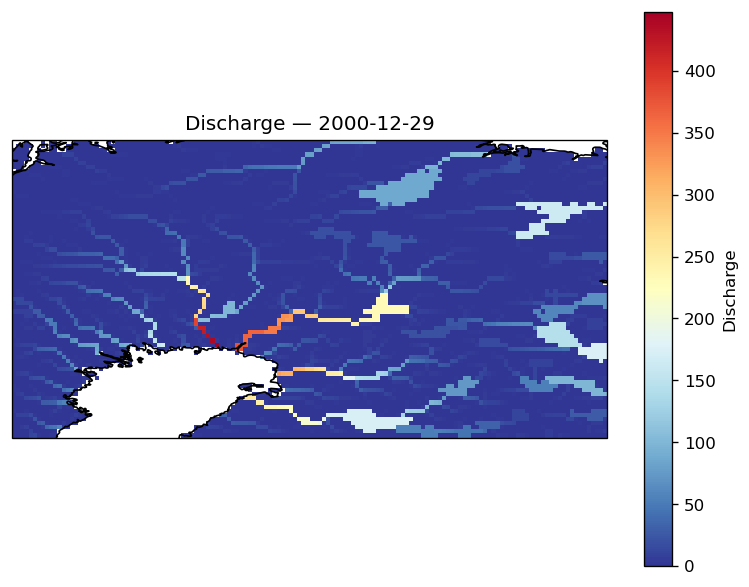

In [53]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

nc_path = "./kemijoki_experiment/netcdf/discharge_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ds["discharge"].isel(time=-1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    cbar_kwargs={"label": "Discharge"},
)

ax.coastlines()
ax.set_title(f"Discharge — {ds.time.isel(time=-1).dt.strftime('%Y-%m-%d').item()}")

plt.show()

Requested: lat=40.81, lon=0.52
Selected:  lat=65.79166412353516, lon=24.54166603088379


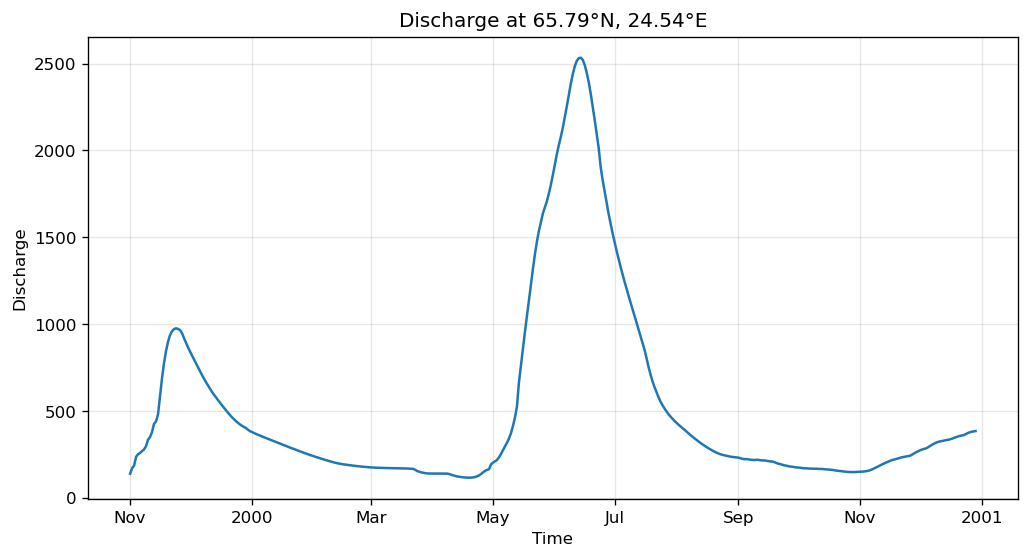

In [ ]:
# Select nearest grid cell to the requested location
point = ds["discharge"].sel(
    lat=65.792,
    lon=24.54,
    method="nearest",
)


# Plot time series
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

point.plot(ax=ax)

ax.set_xlabel("Time")
ax.set_ylabel("Discharge")
ax.set_title(
    f"Discharge at {point.lat.values:.2f}°N, "
    f"{point.lon.values:.2f}°E"
)

ax.grid(True, alpha=0.3)

plt.show()

In [70]:
# eWaterCycle observation module
from ewatercycle.observation.grdc import get_grdc_data
station_id = "6854700"

grdc_start_date = "1996-01-01T00:00:00Z"
grdc_end_date   = "2000-12-31T00:00:00Z"

In [71]:
observations_ds = get_grdc_data(
    station_id=station_id,
    start_time=grdc_start_date,
    end_time=grdc_end_date, 
)

Text(0, 0.5, 'Discharge (m³/s)')

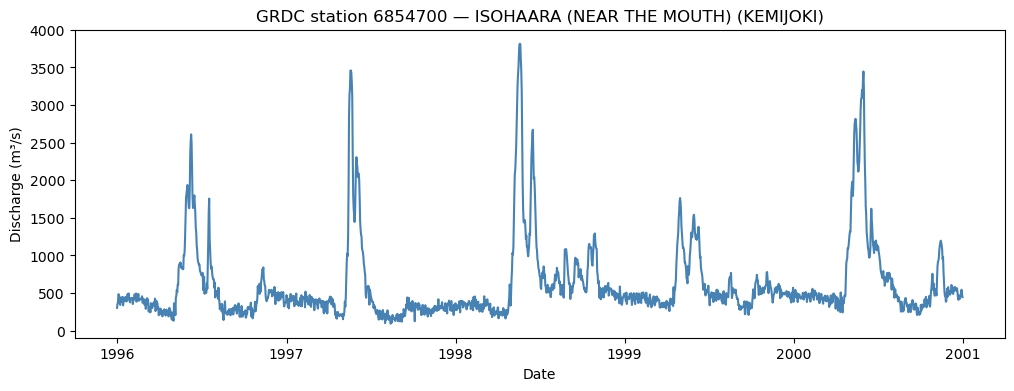

In [72]:
station_name = str(observations_ds["station_name"].values)
river_name   = str(observations_ds["river_name"].values)

# Mask the -999 missing value sentinel before plotting
streamflow = observations_ds["streamflow"].where(observations_ds["streamflow"] != -999)

plt.figure(figsize=(12, 4))
streamflow.plot(color="steelblue")
plt.title(f"GRDC station {station_id} — {station_name} ({river_name})")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
# plt.tight_layout()

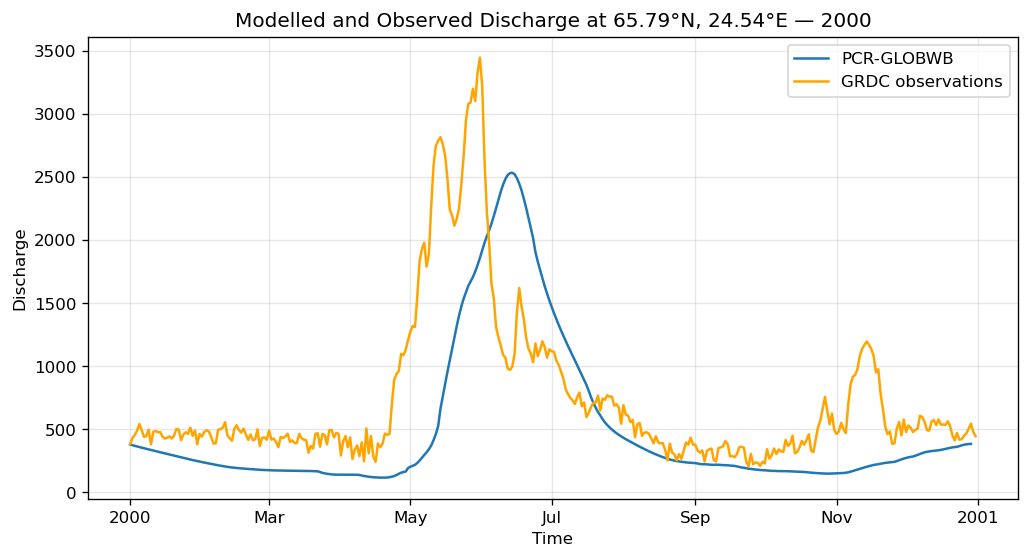

In [73]:
# Select only 2000
point_2000 = point.sel(time=slice("2000-01-01", "2000-12-31"))
streamflow_2000 = streamflow.sel(time=slice("2000-01-01", "2000-12-31"))



# Plot time series
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

point_2000.plot(ax=ax, label="PCR-GLOBWB")
streamflow_2000.plot(ax=ax, color="orange", label="GRDC observations")

ax.set_xlabel("Time")
ax.set_ylabel("Discharge")
ax.set_title(
    f"Modelled and Observed Discharge at {point.lat.values:.2f}°N, "
    f"{point.lon.values:.2f}°E — 2000"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()